# Image Compression

KMeans are widely used in one specific case, which is image compression. Let's test this feature a little bit.

0. Import usuals librairies

In [1]:
#!pip install -q xgboost
#!pip install -q s3fs
 #!pip install -U kaleido

# Load in our libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "colab" # pour que colab ne bloque pas l'export svg

import warnings
warnings.filterwarnings('ignore')

# datasets
from sklearn.datasets import load_sample_image

# pipeline transfomers
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# split
from sklearn.model_selection import train_test_split, GridSearchCV

# regression
from sklearn.linear_model import LogisticRegression, Ridge

# arbres de décision
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# import ensemble methods
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, VotingRegressor, StackingClassifier,  StackingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor, XGBClassifier

# metrics
from sklearn.metrics import r2_score, accuracy_score, silhouette_score

### ML non supervisé
from sklearn.cluster import KMeans, MiniBatchKMeans

# montage drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. In Scikit Learn, import _load_sample_image_ and load “china.jpg” or “flower.jpg” picture

array([[[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        ...,
        [250, 251, 255],
        [250, 251, 255],
        [250, 251, 255]],

       [[172, 199, 229],
        [173, 200, 230],
        [173, 200, 230],
        ...,
        [251, 252, 255],
        [251, 252, 255],
        [251, 252, 255]],

       [[174, 201, 231],
        [174, 201, 231],
        [174, 201, 231],
        ...,
        [252, 253, 255],
        [252, 253, 255],
        [252, 253, 255]],

       ...,

       [[ 88,  80,   7],
        [147, 138,  69],
        [122, 116,  38],
        ...,
        [ 39,  42,  33],
        [  8,  14,   2],
        [  6,  12,   0]],

       [[122, 112,  41],
        [129, 120,  53],
        [118, 112,  36],
        ...,
        [  9,  12,   3],
        [  9,  15,   3],
        [ 16,  24,   9]],

       [[116, 103,  35],
        [104,  93,  31],
        [108, 102,  28],
        ...,
        [ 43,  49,  39],
        [ 13,  21,   6],
        [ 15,  24,   7]]], dtype=uint8)
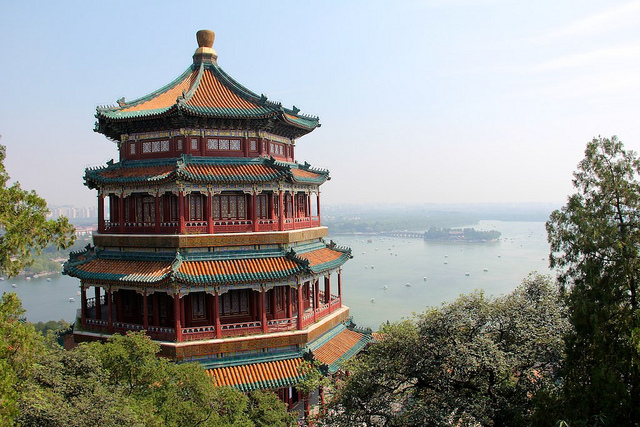

In [2]:
image = load_sample_image("china.jpg")
image


2. With plotly express, diplay your picture

      a. Hint : we will use _imshow_

In [3]:
px.imshow(image)


  3. Look at the dataset's shape

In [4]:
print(image.shape)


(427, 640, 3)


----> Our dataset is split between the height of the pixel, the width of the pixel and its color in RGB

4. Divide your dataset by 255 then resize it in two dimensions (length x width, RGB).

  a. Hint: You can use the ```.reshape()``` method.

In [5]:
image_norm = image / 255
pixels = image_norm.reshape(-1, 3)
# 3 pour que chaque ligne du tableau contiennent les 3 canaux Rouge Vert Bleu
#-1 pour que numpy calclule automatiquement le total de pixels 427 * 640
#
print(pixels.shape)


(273280, 3)


5. We will reduce the number of colours to 16. To do this create a KMeans algorithm that will take 16 clusters.


Instead of using KMeans, you can use [MiniBatchKMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MiniBatchKMeans.html)

In [6]:
kmeans = MiniBatchKMeans(n_clusters=16)
# MiniBatchKMeans diffère du KMeans car il s'entraîne sur des mini-lots (mini-batches)
# au lieu d'utiliser l'ensemble complet des données à chaque itération.
# → Cela le rend beaucoup plus rapide et scalable sur les grandes images.
kmeans.fit(pixels)
# pas de fit_predict ici parce que :
# fit_predict entraîne le modèle ET retourne directement les labels.
# Ici, nous voulons :
#   1) entraîner le modèle (fit)
#   2) récupérer séparément les labels (kmeans.labels_) pour réassigner les couleurs dans (compressed_image).
# avec les 3 dimensions de l'image originale (image.shape)


MiniBatchKMeans(n_clusters=16)

6. For each of the colors present in your dataset, reassign the color code of the centroid of the corresponding cluster in a variable that we will call _new_colors_ .

In [7]:
new_colors = kmeans.cluster_centers_[kmeans.labels_]
print(new_colors.shape) # impossible de px.imshow(new_colors)

(273280, 3)


7. Resize _new_colors_ to 3 dimensions

In [8]:
compressed_image = new_colors.reshape(image.shape)
print(compressed_image.shape)

(427, 640, 3)


8. Visualize your new image with your variable _new_colors_.

In [9]:
px.imshow(compressed_image)


Résultat : image compressée, beaucoup plus légère utilisant seulement 16 couleurs mais visuellemnt très proche de l'originale